In [1]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
tfds.list_builders()

['abstract_reasoning',
 'accentdb',
 'aeslc',
 'aflw2k3d',
 'ag_news_subset',
 'ai2_arc',
 'ai2_arc_with_ir',
 'ai2dcaption',
 'aloha_mobile',
 'amazon_us_reviews',
 'anli',
 'answer_equivalence',
 'arc',
 'asimov_dilemmas_auto_val',
 'asimov_dilemmas_scifi_train',
 'asimov_dilemmas_scifi_val',
 'asimov_injury_val',
 'asimov_multimodal_auto_val',
 'asimov_multimodal_manual_val',
 'asimov_v2_constraints_with_rationale',
 'asimov_v2_constraints_without_rationale',
 'asimov_v2_injuries',
 'asimov_v2_videos',
 'asqa',
 'asset',
 'assin2',
 'asu_table_top_converted_externally_to_rlds',
 'austin_buds_dataset_converted_externally_to_rlds',
 'austin_sailor_dataset_converted_externally_to_rlds',
 'austin_sirius_dataset_converted_externally_to_rlds',
 'bair_robot_pushing_small',
 'bc_z',
 'bccd',
 'beans',
 'bee_dataset',
 'beir',
 'berkeley_autolab_ur5',
 'berkeley_cable_routing',
 'berkeley_fanuc_manipulation',
 'berkeley_gnm_cory_hall',
 'berkeley_gnm_recon',
 'berkeley_gnm_sac_son',
 'berkel

In [3]:
train_split, valid_split = ["train[:90%]", "train[90%:]"]

# Get training data
train_data, info = tfds.load("cifar10", split=train_split, with_info=True)

# Get valid data
valid_data = tfds.load("cifar10", split=valid_split)

# Get test data
test_data = tfds.load("cifar10", split=tfds.Split.TEST)

In [4]:
print(info)

tfds.core.DatasetInfo(
    name='cifar10',
    full_name='cifar10/3.0.2',
    description="""
    The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images.
    """,
    homepage='https://www.cs.toronto.edu/~kriz/cifar.html',
    data_dir='/home/dream/tensorflow_datasets/cifar10/3.0.2',
    file_format=tfrecord,
    download_size=162.17 MiB,
    dataset_size=132.40 MiB,
    features=FeaturesDict({
        'id': Text(shape=(), dtype=string),
        'image': Image(shape=(32, 32, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test': <SplitInfo num_examples=10000, num_shards=1>,
        'train': <SplitInfo num_examples=50000, num_shards=1>,
    },
    citation="""@TECHREPORT{Krizhevsky09learningmultiple,
        author = {A

In [5]:
labels_dict = dict(enumerate(info.features["label"].names))
labels_dict

{0: 'airplane',
 1: 'automobile',
 2: 'bird',
 3: 'cat',
 4: 'deer',
 5: 'dog',
 6: 'frog',
 7: 'horse',
 8: 'ship',
 9: 'truck'}

In [6]:
# Create a dict to count the number of tags in each category
train_dict = {}

# Read the entire training dataset
for data in train_data:
    # Convert the read label to numpy format
    label = data["label"].numpy()

    #Count the number of each category, use a dictionary
    train_dict[label] = train_dict.setdefault(label, 0) + 1

print(train_dict)

{np.int64(7): 4500, np.int64(8): 4456, np.int64(4): 4497, np.int64(6): 4505, np.int64(5): 4503, np.int64(2): 4522, np.int64(9): 4453, np.int64(3): 4526, np.int64(0): 4530, np.int64(1): 4508}


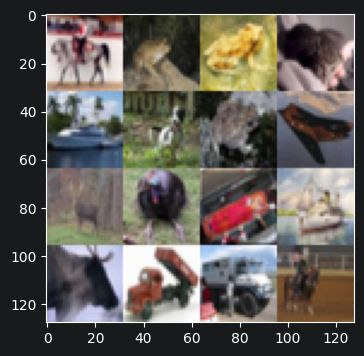

In [7]:
# Create an array to display images
output = np.zeros((32 * 4, 32 * 4, 3), dtype=np.uint8)
row = 0

for data in train_data.batch(4).take(4):
    output[:, row * 32: (row + 1) * 32] = np.vstack(data["image"].numpy())
    row += 1

# Set the display window size
plt.figure(figsize=(4, 4))

# Display image
plt.imshow(output)

In [8]:
def parse_fn(dataset):
    # Image standardization
    x = tf.cast(dataset["image"], tf.float32) / 255

    # Convert the output label to One hot encoding
    y = tf.one_hot(dataset["label"], 10)
    return x, y

In [9]:
AUTOTUNE = tf.data.experimental.AUTOTUNE  # Automatic adjustment mode
batch_size = 256  # Batch size
train_num = int(info.splits["train"].num_examples / 10) * 9  # number of training examples

# Shuffle training data
train_data = train_data.shuffle(train_num)

# Training data
train_data = train_data.map(map_func=parse_fn, num_parallel_calls=AUTOTUNE)

# Set the batch size to 64 and turn on prefetch mode
train_data = train_data.batch(batch_size).prefetch(buffer_size=AUTOTUNE)

# Validation data
valid_data = valid_data.map(map_func=parse_fn, num_parallel_calls=AUTOTUNE)

# Set the batch size to 64 and turn on prefetch mode
valid_data = valid_data.batch(batch_size).prefetch(buffer_size=AUTOTUNE)

# Test data
test_data = test_data.map(map_func=parse_fn, num_parallel_calls=AUTOTUNE)

# Set the batch size to 64 and turn on prefetch mode
test_data = test_data.batch(batch_size).prefetch(buffer_size=AUTOTUNE)

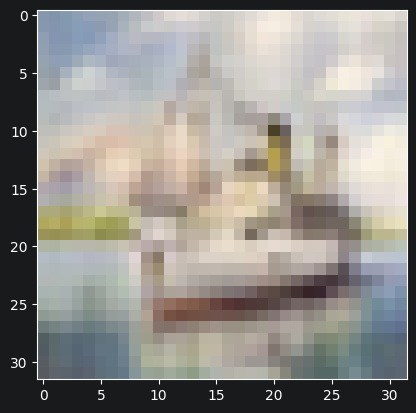

In [10]:
x = 3
y = 2

# Read image
image_test = output[y * 32: (y + 1) * 32, x * 32: (x + 1) * 32, :]

# Display image
plt.imshow(image_test)

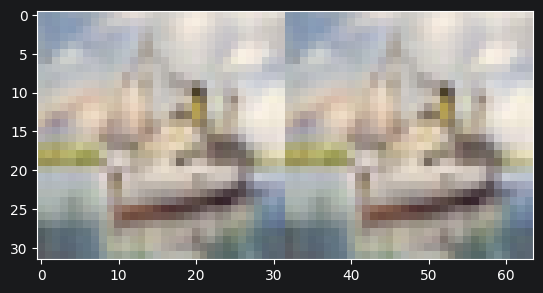

In [11]:
def flip(x):
    """
    flip image
    """
    x = tf.image.random_flip_left_right(x)  # Randomly flip the image
    return x


image_2 = flip(image_test)
image = np.hstack((image_test, image_2))

# Display image
plt.imshow(image)

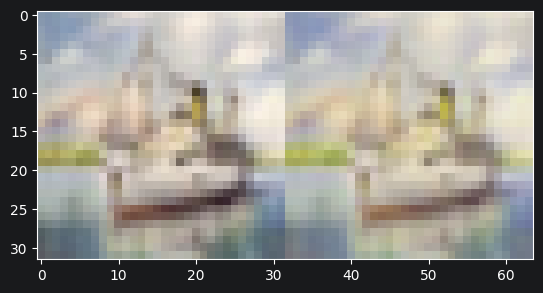

In [12]:
def color(x):
    """
    Color Conversion
    """
    x = tf.image.random_hue(x, 0.08)  # Adjust the hue of image
    x = tf.image.random_saturation(x, 0.6, 1.6)  # adjust image saturation
    x = tf.image.random_brightness(x, 0.05)  # adjust image brightness
    x = tf.image.random_contrast(x, 0.7, 1.3)  # adjust image contrast
    return x


image_2 = color(image_test)
image = np.hstack((image_test, image_2))

# Display image
plt.imshow(image)

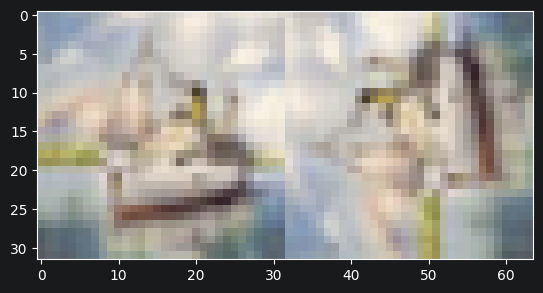

In [13]:
def rotate(x):
    """
    Rotate image
    """
    x = tf.image.rot90(x, tf.random.uniform(shape=[], minval=1, maxval=4, dtype=tf.int32))
    return x


image_2 = rotate(image_test)
image = np.hstack((image_test, image_2))

# Display image
plt.imshow(image)

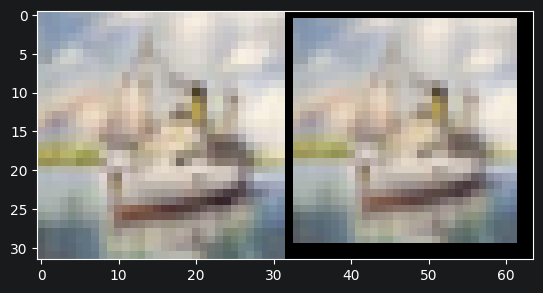

In [14]:
def zoom(x, scale_min=0.6, scale_max=1.4):
    """
    Zoom Image
    """
    h, w, c = x.shape
    scale = tf.random.uniform([], scale_min, scale_max)
    sh = h * scale  # the height of the image after zooming
    sw = w * scale  # the width of image after zooming
    x = tf.image.resize(x, (sh, sw))  # resize
    x = tf.image.resize_with_crop_or_pad(x, h, w)
    return x


image_2 = zoom(image_test)
image_2 = tf.cast(image_2, dtype=tf.uint8)
image = np.hstack((image_test, image_2))

# Display image
plt.imshow(image)

In [15]:
train_data = tfds.load("cifar10", split=train_split)

In [16]:
def parse_aug_fn(dataset):
    """
    Image Augmentation function
    """
    x = tf.cast(dataset["image"], tf.float32) / 255  # Image standardization
    x = flip(x)

    # color conversion
    x = tf.cond(tf.random.uniform([], 0, 1) > 0.5, lambda: color(x), lambda: x)

    # image rotation
    x = tf.cond(tf.random.uniform([], 0, 1) > 0.75, lambda: rotate(x), lambda: x)

    # image zoom
    x = tf.cond(tf.random.uniform([], 0, 1) > 0.5, lambda: zoom(x), lambda: x)

    # Convert the output label to One-hot encoding
    y = tf.one_hot(dataset["label"], 10)
    return x, y

In [17]:
# shuffle data
train_data = train_data.shuffle(train_num)

# Loading data
train_data = train_data.map(map_func=parse_aug_fn, num_parallel_calls=AUTOTUNE)

# Set batch size and turn on prefetch mode
train_data = train_data.batch(batch_size).prefetch(buffer_size=AUTOTUNE)

In [18]:
for images, labels in train_data.take(1):
    images = images.numpy()

    # Create an array to display images
    output = np.zeros((32 * 8, 32 * 8, 3))

    # add 64 data into the array for displaying images

    for i in range(8):
        for j in range(8):
            output[i * 32: (i + 1) * 32, j * 32: (j + 1) * 32, :] = images[i * 8 + j]

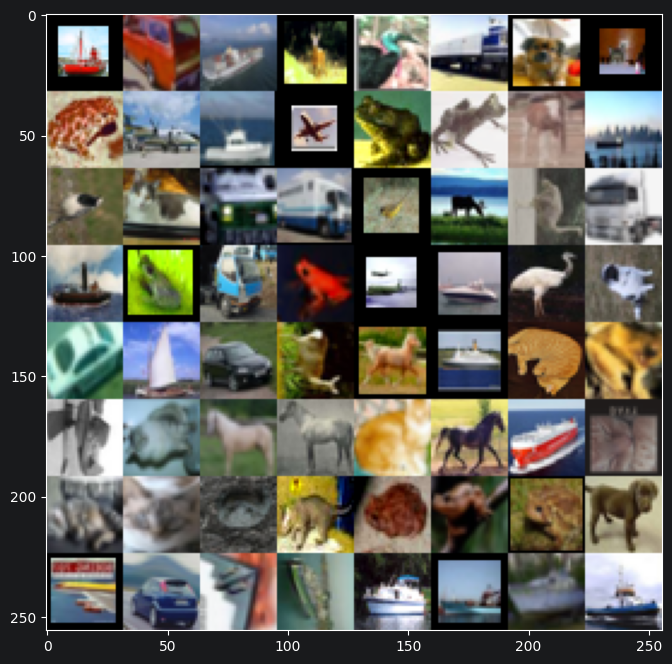

In [19]:
plt.figure(figsize=(8, 8))

# Display image
plt.imshow(output)

In [20]:
inputs = keras.Input(shape=(32, 32, 3))
x = layers.Flatten()(inputs)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(10, activation="softmax")(x)

# Create a network model
model_1 = keras.Model(inputs, outputs, name="model-1")
model_1.summary()  # Show network architecture

Model: "model-1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 969,034 (3.70 MB)

 Trainable params: 969,034 (3.70 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model_dir = "models"
os.makedirs(model_dir, exist_ok=True)

In [22]:
# Save the training records as TensorBoard log files
log_dir = "model-1"
model_cbk = keras.callbacks.TensorBoard(log_dir=log_dir)

# Save the best model
model_mckp = keras.callbacks.ModelCheckpoint(
        model_dir + "/Best-model-1.keras", monitor="val_categorical_accuracy", save_best_only=True, mode="max"
)

In [23]:
model_1.compile(
        keras.optimizers.Adam(), loss=keras.losses.CategoricalCrossentropy(),
        metrics=[keras.metrics.CategoricalAccuracy()]
)

In [24]:
history_1 = model_1.fit(train_data, epochs=100, validation_data=valid_data, callbacks=[model_cbk, model_mckp])

Epoch 1/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 32s 107ms/step - categorical_accuracy: 0.1940 - loss: 2.1430 - val_categorical_accuracy: 0.3068 - val_loss: 1.9076
Epoch 2/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - categorical_accuracy: 0.2623 - loss: 2.0065 - val_categorical_accuracy: 0.3474 - val_loss: 1.8310
Epoch 3/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - categorical_accuracy: 0.2938 - loss: 1.9523 - val_categorical_accuracy: 0.3708 - val_loss: 1.7690
Epoch 4/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - categorical_accuracy: 0.3140 - loss: 1.9039 - val_categorical_accuracy: 0.3824 - val_loss: 1.7291
Epoch 5/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - categorical_accuracy: 0.3308 - loss: 1.8722 - val_categorical_accuracy: 0.3888 - val_loss: 1.7165
Epoch 6/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - categorical_accuracy: 0.3439 - loss: 1.8334 - val_categorical_accuracy: 0.4060 - val_loss: 1.6647
Epoch 7/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - categorical_accura

In [25]:
inputs = keras.Input(shape=(32, 32, 3))
x = layers.Conv2D(64, (3, 3), activation="relu")(inputs)
x = layers.MaxPool2D()(x)
x = layers.Conv2D(128, (3, 3), activation="relu")(x)
x = layers.Conv2D(256, (3, 3), activation="relu")(x)
x = layers.Conv2D(128, (3, 3), activation="relu")(x)
x = layers.Conv2D(64, (3, 3), activation="relu")(x)
x = layers.Flatten()(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(10, activation="softmax")(x)

# Create model
model_2 = keras.Model(inputs, outputs, name="model-2")
model_2.summary()  # Show network architecture

Model: "model-2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 9, 9, 128)      │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 941,066 (3.59 MB)

 Trainable params: 941,066 (3.59 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
log_dir = "model-2"
model_cbk = keras.callbacks.TensorBoard(log_dir=log_dir)

# Save the best model
model_mckp = keras.callbacks.ModelCheckpoint(
        model_dir + "/Best-model-2.keras", monitor="val_categorial_accuracy", save_best_only=True, mode="max"
)

In [27]:
model_2.compile(
        keras.optimizers.Adam(), loss=keras.losses.CategoricalCrossentropy(),
        metrics=[keras.metrics.CategoricalAccuracy()]
)

In [28]:
history_2 = model_2.fit(train_data, epochs=100, validation_data=valid_data, callbacks=[model_cbk, model_mckp])

Epoch 1/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 26s 86ms/step - categorical_accuracy: 0.1763 - loss: 2.1661 - val_categorical_accuracy: 0.2958 - val_loss: 1.9561
Epoch 2/100


/home/dream/.virtualenvs/LLM/lib/python3.11/site-packages/keras/src/callbacks/model_checkpoint.py:329: UserWarning: Can save best model only with val_categorial_accuracy available.
  if self._should_save_model(epoch, batch, logs, filepath):


176/176 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - categorical_accuracy: 0.2408 - loss: 2.0171 - val_categorical_accuracy: 0.3772 - val_loss: 1.7206
Epoch 3/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - categorical_accuracy: 0.3017 - loss: 1.8801 - val_categorical_accuracy: 0.4416 - val_loss: 1.5463
Epoch 4/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - categorical_accuracy: 0.3466 - loss: 1.7747 - val_categorical_accuracy: 0.4746 - val_loss: 1.4333
Epoch 5/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - categorical_accuracy: 0.3810 - loss: 1.6874 - val_categorical_accuracy: 0.5102 - val_loss: 1.3630
Epoch 6/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - categorical_accuracy: 0.4105 - loss: 1.6169 - val_categorical_accuracy: 0.5428 - val_loss: 1.2528
Epoch 7/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - categorical_accuracy: 0.4340 - loss: 1.5654 - val_categorical_accuracy: 0.5630 - val_loss: 1.2104
Epoch 8/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - categorical_accuracy: 0.4586 - l

In [29]:
inputs = keras.Input(shape=(32, 32, 3))
x = layers.Conv2D(64, (3, 3), activation="relu")(inputs)
x = layers.MaxPool2D()(x)
x = layers.Conv2D(128, (3, 3), activation="relu")(x)
x = layers.Conv2D(256, (3, 3), activation="relu")(x)
x = layers.Conv2D(128, (3, 3), activation="relu")(x)
x = layers.Conv2D(64, (3, 3), activation="relu")(x)
x = layers.Flatten()(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(10, activation="softmax")(x)

# Create model
model_3 = keras.Model(inputs, outputs, name="model-3")

# Show network architecture
model_3.summary()

Model: "model-3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 30, 30, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 13, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 9, 9, 128)      │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 7, 7, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 941,066 (3.59 MB)

 Trainable params: 941,066 (3.59 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# Save training records as TensorBoard log files
log_dir = "model-3"
model_cbk = keras.callbacks.TensorBoard(log_dir=log_dir)

In [31]:
# Save the best model
model_mckp = keras.callbacks.ModelCheckpoint(
        model_dir + "/Best-model-3.keras", monitor="val_categorial_accuracy", save_best_only=True, mode="max"
)

In [32]:
model_3.compile(
        keras.optimizers.Adam(), loss=keras.losses.CategoricalCrossentropy(),
        metrics=[keras.metrics.CategoricalAccuracy()]
)

In [33]:
history_3 = model_3.fit(train_data, epochs=100, validation_data=valid_data, callbacks=[model_cbk, model_mckp])

Epoch 1/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step - categorical_accuracy: 0.2102 - loss: 2.0951 - val_categorical_accuracy: 0.3622 - val_loss: 1.7313
Epoch 2/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - categorical_accuracy: 0.3089 - loss: 1.8694 - val_categorical_accuracy: 0.4456 - val_loss: 1.5252
Epoch 3/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - categorical_accuracy: 0.3645 - loss: 1.7375 - val_categorical_accuracy: 0.4846 - val_loss: 1.4076
Epoch 4/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - categorical_accuracy: 0.4007 - loss: 1.6542 - val_categorical_accuracy: 0.5372 - val_loss: 1.2971
Epoch 5/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - categorical_accuracy: 0.4307 - loss: 1.5736 - val_categorical_accuracy: 0.5710 - val_loss: 1.2014
Epoch 6/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - categorical_accuracy: 0.4568 - loss: 1.5153 - val_categorical_accuracy: 0.5760 - val_loss: 1.1648
Epoch 7/100
176/176 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - categorical_accurac

In [34]:
model_1.load_weights("models/Best-model-1.keras")
model_2.load_weights("models/Best-model-2.keras")
model_3.load_weights("models/Best-model-3.keras")

In [35]:
loss_1, acc_1 = model_1.evaluate(test_data)
loss_2, acc_2 = model_2.evaluate(test_data)
loss_3, acc_3 = model_3.evaluate(test_data)

40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - categorical_accuracy: 0.5004 - loss: 1.4140
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - categorical_accuracy: 0.8146 - loss: 0.5734
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - categorical_accuracy: 0.8239 - loss: 0.5704


In [36]:
loss = [loss_1, loss_2, loss_3]
acc = [acc_1, acc_2, acc_3]
dict = {"Accuracy": acc, "Loss": loss}
pd.DataFrame(dict)

,Accuracy,Loss
0,0.5004,1.413967
1,0.8146,0.573404
2,0.8239,0.570409
